In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.style.use('sci.mplstyle')

In [3]:
#u[i, 0]     = bottom
#u[i, n-1]   = top
#u[0, j]     = left
#u[n-1, j]   = right

def tao_bien_hinhvuong(n, u_bottom, u_left, u_right, u_top):
    u = np.zeros((n, n), dtype=float)

    u[:, 0] = u_bottom
    u[:, -1] = u_top
    u[0, :] = u_left
    u[-1, :] = u_right

    return u

In [4]:
def luu_file(filename, u, err, L, k):
    n = u.shape[0]

    with open(filename, "w", encoding="utf-8") as file:
        file.write(f"### Ket qua tai vong lap {k}\n")
        file.write(f"### Max error = {np.max(err):.6e}\n")
        file.write("#" * 80 + "\n")
        file.write(f"### {'x':>15s} {'y':>15s} {'V':>15s} {'Error':>15s}\n")

        for i in range(n):
            for j in range(n):
                x = i * L / (n - 1)
                y = j * L / (n - 1)
                file.write(f"    {x:15.6f} {y:15.6f} {u[i,j]:15.6f} {err[i,j]:15.6e}\n")
            file.write("\n")

In [5]:
# u        : mang nghiem kich thuoc n x n, da gan san dieu kien bien
# L        : chieu dai mien tinh toan, vi du mien [0, L] x [0, L]
# N_max    : so lan lap toi da neu chua hoi tu
# err_max  : nguong sai so hoi tu, dung khi max|u_moi - u_cu| < err_max
# filename : ten file output dung de luu nghiem va sai so

def hamtinh_laplace_gauss_seidel(u, L, N_max=100000, err_max=1e-6, filename="bai1"):
    global h, rho, x, y
    n = u.shape[0]  # kich thuoc luoi n x n

    for k in range(N_max):
        u_old = u.copy()  # luu nghiem cua vong lap truoc

        # cap nhat cac diem ben trong theo cong thuc Gauss-Seidel
        for i in range(1, n - 1):
            for j in range(1, n - 1):
                u[i, j] = 0.25 * (
                    u[i + 1, j]  # diem ben phai
                    + u[i - 1, j]  # diem ben trai
                    + u[i, j + 1]  # diem ben tren
                    + u[i, j - 1]  # diem ben duoi
                    #+ h**2 * np.pi * rho(x[i], y[j]) 

                )
        # khi dang tinh u[i,j] thi u[i+1, j] va u[i, j + 1] la chua cap nhat nen no la old
        # trong khi do u[i-1, j] va u[i, j - 1] la chap nhat roi nen no la new

        # tinh sai so giua hai lan lap lien tiep
        err = np.abs(u - u_old)

        # lay sai so lon nhat tren toan bo luoi
        max_err = np.max(err)

        # kiem tra dieu kien hoi tu
        if max_err < err_max:
            print(f"Gauss-Seidel hoi tu sau {k} vong lap, max_err = {max_err:.3e}")

            # luu nghiem va sai so ra file
            luu_file(filename + "_gs_result.txt", u, err, L, k)

            return u

    # truong hop khong hoi tu sau N_max vong lap
    print(f"Gauss-Seidel khong hoi tu sau {N_max} vong lap, max_err = {max_err:.3e}")
    # luu ket qua cuoi cung ra file
    luu_file(filename + "_gs_result_khonghoitu.txt", u, err, L, N_max)

    return u

# Bai toan tinh dien 100 V phia tren, 0 V xung quanh


In [5]:
L = 100 # Chieu dai
n = 100   # so diem chia

# Dung khi su dung them rho khac 0 (co tich dien)
#h = L / (n - 1)  # bước lưới

#x = np.linspace(0, L, n)
#y = np.linspace(0, L, n)

#def rho(x, y):
#    return 0.0


N_max = 100000 # So vong lap toi da
err_max = 1e-6 # Sai so

V_xungquanh = 0 # Dien the
V_trencung = 100 # Dien the

u_hinhxuong_thanh100 = tao_bien_hinhvuong(n, V_xungquanh, V_xungquanh, V_xungquanh, V_trencung)

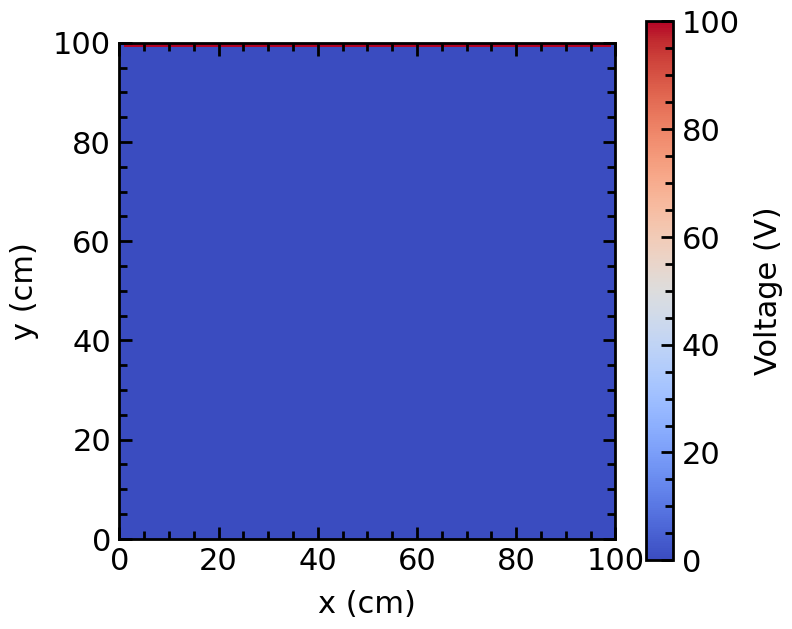

In [6]:
plt.figure(figsize=(8, 7))
plt.imshow(u_hinhxuong_thanh100.T, origin='lower', cmap='coolwarm', extent=[0,100,0,100]) 
#.T laf transpose do matplotlib ve anh theo kieu u[i, j] voi i la y, j la x. Tuy nhien define lai nguoc lai
plt.xlabel('x (cm)')
plt.ylabel('y (cm)')
plt.colorbar(label='Voltage (V)')
plt.show()

In [27]:
h = 0

u_gauss = hamtinh_laplace_gauss_seidel(u_hinhxuong_thanh100, L, N_max=100000, err_max=1e-6, filename="bai1")

Gauss-Seidel hoi tu sau 10566 vong lap, max_err = 9.995e-07


In [ ]:
def doc_file_ketqua(filename): #dung de doc file ket qua
    x, y, V, err = np.loadtxt(filename, unpack=True, comments="#")

    # Lay so diem luoi that su tu file
    x_unique = np.unique(x)
    y_unique = np.unique(y)

    nx = len(x_unique)
    ny = len(y_unique)

    print("File:", filename)
    print("nx =", nx)
    print("ny =", ny)
    print("So diem trong file =", len(x))
    print("nx * ny =", nx * ny)

    if nx * ny != len(x):
        raise ValueError("File khong phai luoi chu nhat day du")

    # Neu file luu theo for i rồi for j
    X = x.reshape(nx, ny)
    Y = y.reshape(nx, ny)
    V2D = V.reshape(nx, ny)
    err2D = err.reshape(nx, ny)

    return x_unique, y_unique, X, Y, V2D, err2D

File: bai1_gs_result.txt
nx = 100
ny = 100
So diem trong file = 10000
nx * ny = 10000


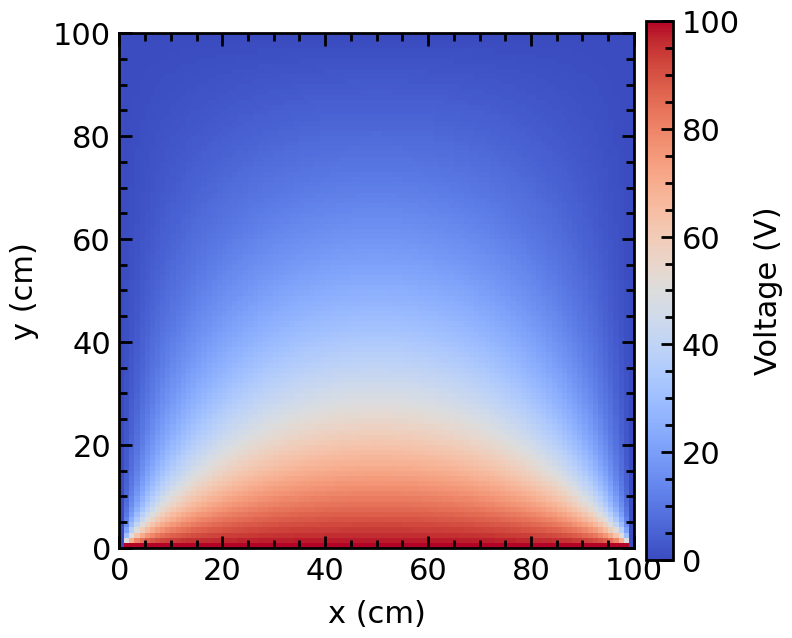

In [7]:
x_unique_gs_bai1, y_unique_gs_bai1, X_gs_bai1, Y_gs_bai1, V2D_gs_bai1, err2D_gs_bai1 =  doc_file_ketqua("bai1_gs_result.txt")

#norm = mcolors.Normalize(vmin=-100, vmax=100)

plt.figure(figsize=(8, 7))
plt.imshow(V2D_gs_bai1.T, cmap='coolwarm', extent=(0,100,0,100))
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.xlabel('x (cm)')
plt.ylabel('y (cm)')
cb = plt.colorbar(label='Voltage (V)', orientation='vertical', pad=0.02)

cb.set_ticks(np.arange(0, 101, 20))
plt.savefig("BT1-PDE-Thetinhdien-bai1-gs.png", dpi=300)
plt.show()

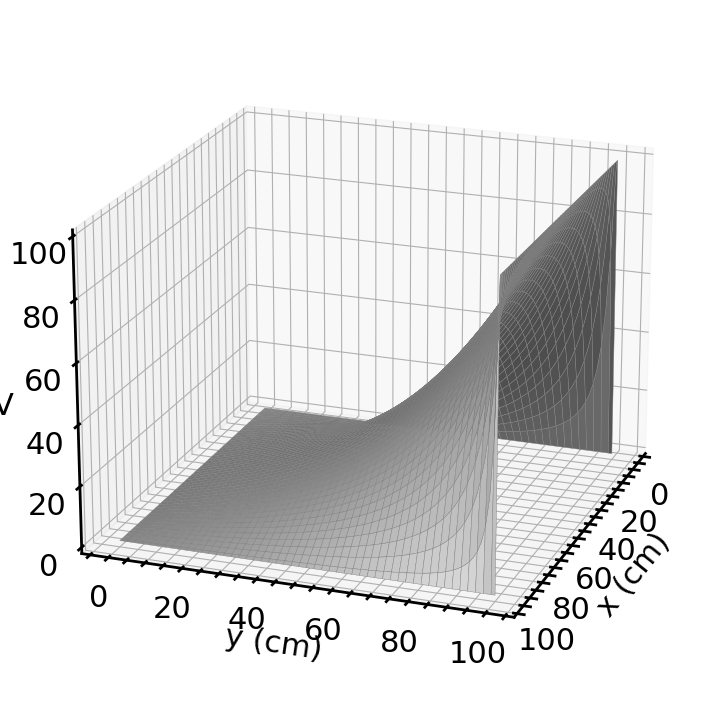

In [8]:
fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X_gs_bai1, Y_gs_bai1, V2D_gs_bai1, color='white', edgecolor='gray', linewidth=0.3)
ax.set_xlabel('x (cm)')
ax.set_ylabel('y (cm)')
ax.set_zlabel('V')
ax.view_init(elev=20, azim=20)
plt.savefig("BT1-PDE-Thetinhdien-bai1-gs-3D.png", dpi=300)
plt.show()

# Bai tap tinh dien 2 thanh

In [30]:
def dieukienbien_bai2(n, u_bien, u_thap, u_cao, chieudai, chieurong, L):

    #length nhap vo la chieu ngang/boundary ngang, width nhap vo la chieu doc/boundary doc

    u = np.zeros((n, n), dtype=float)

    # u[i,0] = bottom
    for i in range(n):
        u[i, 0] = u_bien

    # u[0,j] = left
    for j in range(n):
        u[0, j] = u_bien

    # u[n-1,j] = right
    for j in range(n):
        u[n-1, j] = u_bien

    # u[i,n-1] = top
    for i in range(n):
        u[i, n-1] = u_bien

    # Thanh co chieu ngang tu (n-chieudai)/2 den (n+chieudai)/2, chieu doc nam o n+(chieurong/2) co dien ap u_cao
    # Thanh co chieu ngang tu (n-chieudai)/2 den (n+chieudai)/2, chieu doc nam o n-(chieurong/2) co dien ap u_thap

    n_chieudai  = int(chieudai  / L * (n - 1))   # 50/100 * 99 = 49
    n_chieurong = int(chieurong / L * (n - 1))   # 30/100 * 99 = 29

    n_center = n // 2
    thanh_o_tren = n_center + n_chieurong // 2
    thanh_o_duoi = n_center - n_chieurong // 2

    start  = (n-n_chieudai) // 2
    end = start + n_chieudai

    for i in range(start, end):
        u[i, thanh_o_tren] = u_cao
        u[i, thanh_o_duoi] = u_thap

    return u, start, end, thanh_o_tren, thanh_o_duoi
# start         : chi so i bat dau cua hai thanh dan theo phuong ngang
# end           : chi so i ket thuc cua hai thanh dan theo phuong ngang
# thanh_o_tren  : chi so j cua thanh tren, thanh nay duoc gan dien the u_cao
# thanh_o_duoi  : chi so j cua thanh duoi, thanh nay duoc gan dien the u_thap

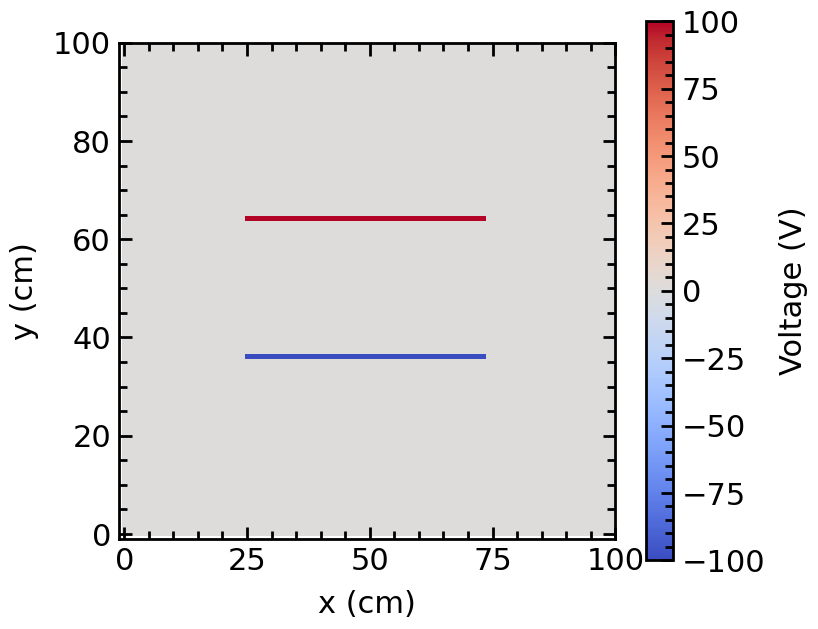

In [31]:
L = 100
n = 100
u_bien = 0
u_thap = -100
u_cao = 100
chieudai = 50
chieurong = 30


# Kiem tra dieu kien bien 
u_bien_bai2, start_bai2, end_bai2, thanh_o_tren_bai2, thanh_o_duoi_bai2 = dieukienbien_bai2(n, u_bien, u_thap, u_cao, chieudai, chieurong, L)
plt.figure(figsize=(8, 7))
plt.imshow(u_bien_bai2.T, origin='lower', cmap='coolwarm')
plt.xlim(-1, 100)
plt.ylim(-1, 100)
plt.xlabel('x (cm)')
plt.ylabel('y (cm)')
plt.colorbar(label='Voltage (V)')
plt.show()
N_max = 100000
err_max = 1e-6

In [ ]:
# u        : mang nghiem kich thuoc n x n, da gan san dieu kien bien
# L        : chieu dai mien tinh toan, vi du mien [0, L] x [0, L]
# N_max    : so lan lap toi da neu chua hoi tu
# err_max  : nguong sai so hoi tu, dung khi max|u_moi - u_cu| < err_max
# filename : ten file output dung de luu nghiem va sai so
# start         : chi so i bat dau cua hai thanh dan theo phuong ngang
# end           : chi so i ket thuc cua hai thanh dan theo phuong ngang
# thanh_o_tren  : chi so j cua thanh tren, thanh nay duoc gan dien the u_cao
# thanh_o_duoi  : chi so j cua thanh duoi, thanh nay duoc gan dien the u_thap


def hamtinh_laplace_gauss_seidel_codieukien2thanh(u, L, start, end, thanh_o_tren , thanh_o_duoi, N_max=100000, err_max=1e-6, filename="bai2"):
    global h, rho, x, y
    n = u.shape[0]  # kich thuoc luoi n x n

    for k in range(N_max):
        u_old = u.copy()  # luu nghiem cua vong lap truoc

        # cap nhat cac diem ben trong theo cong thuc Gauss-Seidel
        for i in range(1, n - 1):
            for j in range(1, n - 1):
                if start <= i < end and (j == thanh_o_tren or j == thanh_o_duoi):
                    continue
                u[i, j] = 0.25 * (
                    u[i + 1, j]  # diem ben phai
                    + u[i - 1, j]  # diem ben trai
                    + u[i, j + 1]  # diem ben tren
                    + u[i, j - 1]  # diem ben duoi
                    #+ h**2 * np.pi * rho(x[i], y[j]) 

                )
        # khi dang tinh u[i,j] thi u[i+1, j] va u[i, j + 1] la chua cap nhat nen no la old
        # trong khi do u[i-1, j] va u[i, j - 1] la chap nhat roi nen no la new

        # tinh sai so giua hai lan lap lien tiep
        err = np.abs(u - u_old)

        # lay sai so lon nhat tren toan bo luoi
        max_err = np.max(err)

        # kiem tra dieu kien hoi tu
        if max_err < err_max:
            print(f"Gauss-Seidel hoi tu sau {k} vong lap, max_err = {max_err:.3e}")

            # luu nghiem va sai so ra file
            luu_file(filename + "_gs_result.txt", u, err, L, k)

            return u

    # truong hop khong hoi tu sau N_max vong lap
    print(f"Gauss-Seidel khong hoi tu sau {N_max} vong lap, max_err = {max_err:.3e}")
    # luu ket qua cuoi cung ra file
    luu_file(filename + "_gs_result_khonghoitu.txt", u, err, L, N_max)

    return u

In [33]:
u_result_bai2 = hamtinh_laplace_gauss_seidel_codieukien2thanh(u_bien_bai2, 
                                                        L, start=start_bai2, 
                                                        end=end_bai2, 
                                                        thanh_o_tren=thanh_o_tren_bai2, 
                                                        thanh_o_duoi=thanh_o_duoi_bai2,
                                                        N_max=100000, 
                                                        err_max=1e-6, 
                                                        filename="bai2")

Gauss-Seidel hoi tu sau 3009 vong lap, max_err = 9.983e-07


Locator attempting to generate 1001 ticks ([-100.0, ..., 100.0]), which exceeds Locator.MAXTICKS (1000).


File: bai2_gs_result.txt
nx = 100
ny = 100
So diem trong file = 10000
nx * ny = 10000


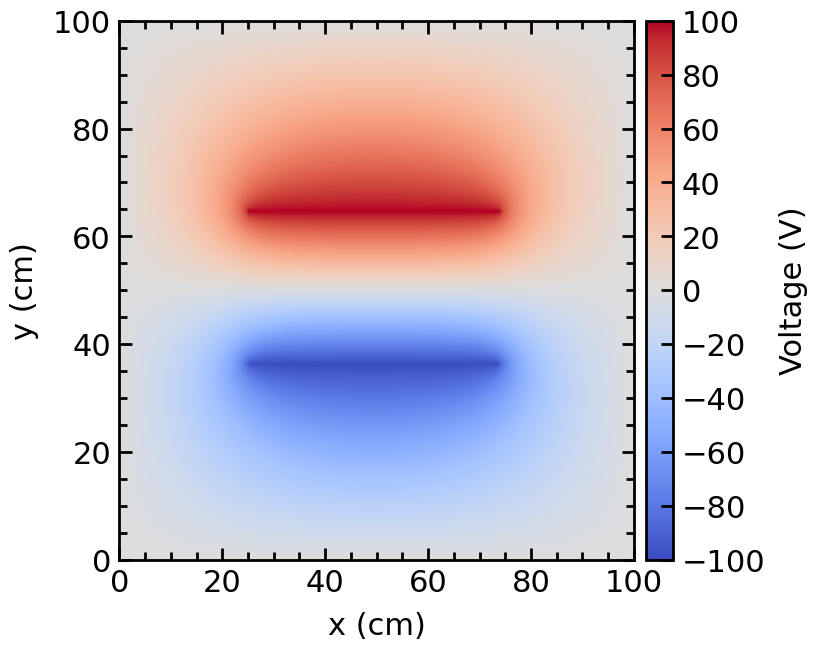

In [15]:
x_unique_gs_bai2, y_unique_gs_bai2, X_gs_bai2, Y_gs_bai2, V2D_gs_bai2, err2D_gs_bai2 =  doc_file_ketqua("bai2_gs_result.txt")


#norm = mcolors.Normalize(vmin=-100, vmax=100)

plt.figure(figsize=(8, 7))
plt.contourf(X_gs_bai2, Y_gs_bai2, V2D_gs_bai2, levels=1000, cmap='coolwarm')
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.xlabel('x (cm)')
plt.ylabel('y (cm)')
cb = plt.colorbar(label='Voltage (V)', orientation='vertical', pad=0.02)

cb.set_ticks(np.arange(-100, 101, 20))
plt.savefig("BT2-PDE-Thetinhdien-bai2-gs.png", dpi=300)
plt.show()

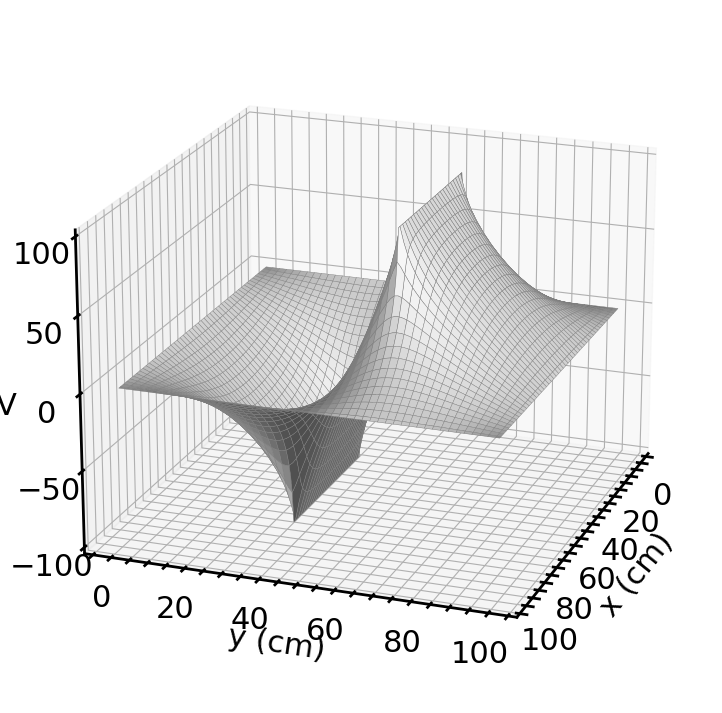

In [16]:
fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection='3d')

X_gs_bai2_ve, Y_gs_bai2_ve = np.meshgrid(X_gs_bai2, Y_gs_bai2) # Gia su neu nhu khong chung shape la khong ve duoc

ax.plot_surface(X_gs_bai2, Y_gs_bai2, V2D_gs_bai2, color='white', edgecolor='gray', linewidth=0.3)
ax.set_xlabel('x (cm)')
ax.set_ylabel('y (cm)')
ax.set_zlabel('V')
ax.view_init(elev=20, azim=20)
plt.savefig("BT2-PDE-Thetinhdien-bai2-gs-3D.png", dpi=300)
plt.show()